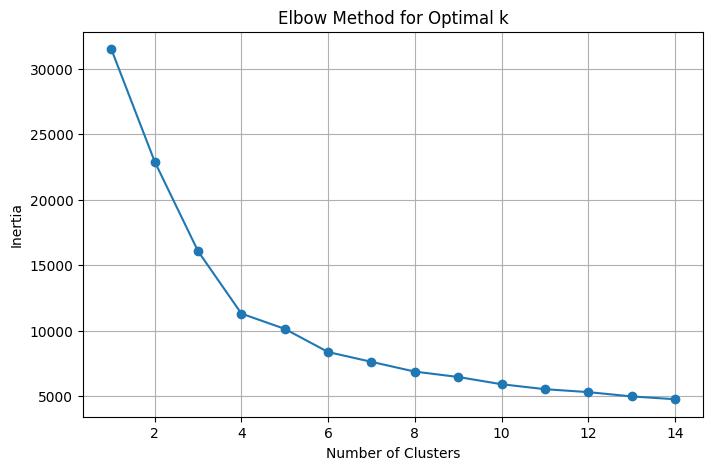

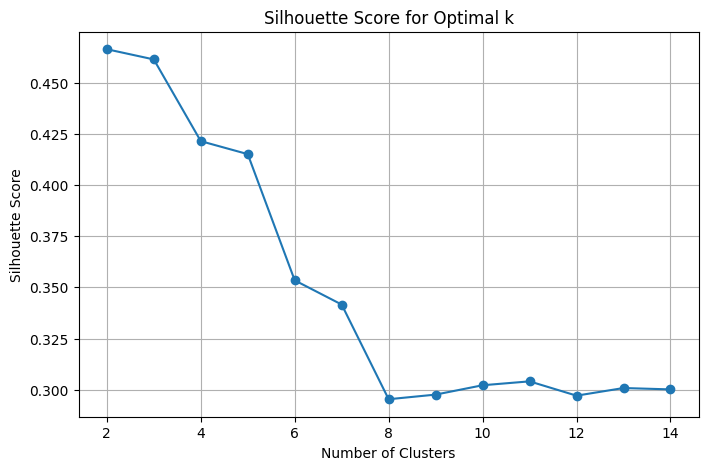

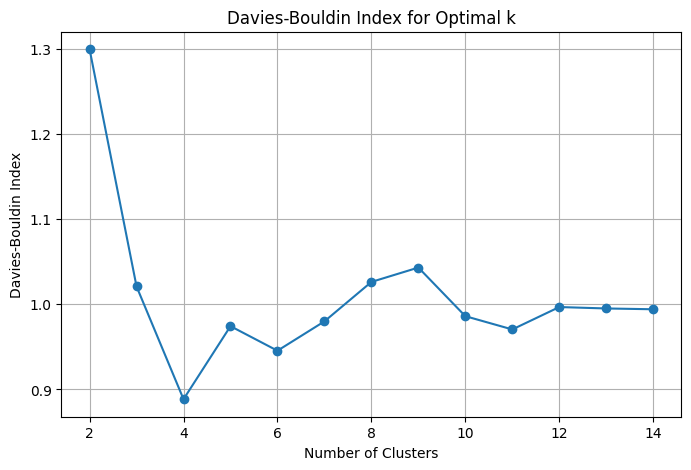

Silhouette Score: 0.4150818838857083


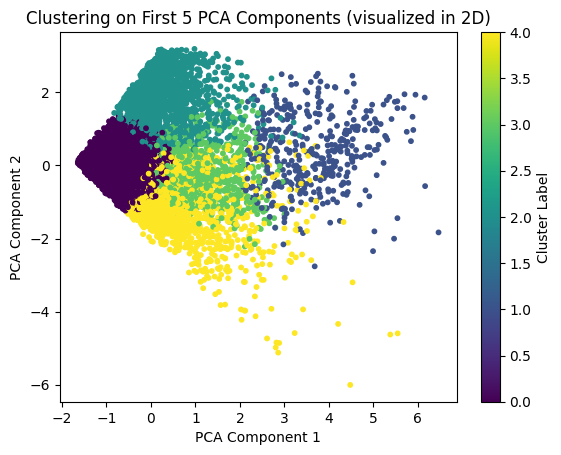

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from wordcloud import WordCloud
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN



# %%
data = pd.read_csv('RAW_recipes.csv')

#data = data.sample(50000)


# %%
# tags_to_keep = ['main-dish', 'cakes', 'chicken', 'low-cholesterol', 'poultry', 'meat', 
#                 'desserts', 'low-saturated-fat', 'high-protein', 'low-protein', 'healthy']

data[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 'protein (PDV)', 
         'saturated fat (PDV)', 'carbohydrates (PDV)']] = data['nutrition'].str.strip('[]').str.split(",", expand=True).astype(float)


data = data[(data["calories"] >= 500) & (data["calories"] <= 2000) & (data['minutes']<300) & (data['protein (PDV)']>20) & (data['saturated fat (PDV)']>20) & 
            (data['carbohydrates (PDV)']>20) & (data['total fat (PDV)']>20) & (data['sugar (PDV)']< 200) & (data['n_ingredients']<20)]


data.drop(['id', 'contributor_id', 'submitted'], axis=1, inplace=True)

index_to_drop = data[data['name'] == 'tennessee moonshine'].index

data = data.drop(index_to_drop).reset_index(drop=True)

index_to_drop = data[data['name'] == 'deep fried prime rib'].index

data = data.drop(index_to_drop).reset_index(drop=True)

# for tag in tags_to_keep:
#     data[tag] = data['tags'].apply(lambda tags: int(tag in tags))

# correlation_matrix = data[['calories', 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 
#                            'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)'] 
#                           + tags_to_keep].corr()

# 
# relevant_correlations = correlation_matrix.loc[tags_to_keep, 
#                                                ['calories', 'total fat (PDV)', 'sugar (PDV)', 
#                                                 'sodium (PDV)', 'protein (PDV)', 'saturated fat (PDV)', 
#                                                 'carbohydrates (PDV)']]


# %%

# Select relevant columns (nutritional values + chosen tags)
# clustering_features = data[['total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)', 
#                             'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)'] 
#                            ]


clustering_features = data[['sugar (PDV)', 
                            'protein (PDV)', 'carbohydrates (PDV)'] ]

# clustering_features = data[[ 'total fat (PDV)', 'sugar (PDV)', 'sodium (PDV)',
#                             'protein (PDV)', 'saturated fat (PDV)', 'carbohydrates (PDV)'] 
#                            ]



scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)



# %%
# pca = PCA(n_components=7)  # Set to the number of features or fewer
# pca.fit(scaled_features)

# explained_variance_ratio = pca.explained_variance_ratio_

# for i, variance in enumerate(explained_variance_ratio):
#     print(f"Component {i+1} explains {variance:.2%} of the variance")
    


# %%
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
cluster_range = range(1, 15)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)  
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(cluster_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid()
plt.show()


# %%
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)  
    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.grid()
plt.show()


# %%
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_features)  
    db_score = davies_bouldin_score(scaled_features, labels)
    db_scores.append(db_score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 15), db_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index for Optimal k')
plt.grid()
plt.show()


# %%
from sklearn.cluster import KMeans
import hdbscan

# clusterer = hdbscan.HDBSCAN(min_samples= 500, min_cluster_size=500)
# cluster_labels = clusterer.fit_predict(pca_features)

kmeans = KMeans(n_clusters=5, random_state=42)  
cluster_labels = kmeans.fit_predict(scaled_features)


# %%
from sklearn.metrics import silhouette_score


silhouette_avg = silhouette_score(scaled_features, cluster_labels)
print(f"Silhouette Score: {silhouette_avg}")


# %%

pca_2d = PCA(n_components=2)
pca_features_2d = pca_2d.fit_transform(scaled_features)


import matplotlib.pyplot as plt

plt.scatter(pca_features_2d[:, 0], pca_features_2d[:, 1], c=cluster_labels, cmap='viridis', s=10)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clustering on First 5 PCA Components (visualized in 2D)')
plt.colorbar(label='Cluster Label')
plt.show()

In [7]:

data_with_clusters = data.copy()  
data_with_clusters['Cluster'] = cluster_labels  


output_file = "clustered_recipes.csv"
data_with_clusters.to_csv(output_file, index=False)

print(f"Clustered dataset saved to '{output_file}'")


Clustered dataset saved to 'clustered_recipes.csv'


In [4]:

data_with_clusters = data.copy()
data_with_clusters['Cluster'] = cluster_labels


samples_per_cluster = 5 
cluster_samples = []

for cluster_id in sorted(data_with_clusters['Cluster'].unique()):
    cluster_data = data_with_clusters[data_with_clusters['Cluster'] == cluster_id]
    sampled_data = cluster_data.sample(min(samples_per_cluster, len(cluster_data)), random_state=42)
    cluster_samples.append(sampled_data)

cluster_samples_df = pd.concat(cluster_samples)


print("Sample Recipes for Each Cluster:")
print(cluster_samples_df[['name', 'Cluster', 'calories', 'protein (PDV)', 'sugar (PDV)', 'carbohydrates (PDV)']])





Sample Recipes for Each Cluster:
                                                    name  Cluster  calories  \
9219          stuffed pork chops with mushroom pan gravy        0    1193.1   
5744   mashed potatoes with caramelized onions and go...        0     673.2   
8875   spaghetti with uncooked tomato sauce southwest...        0     745.2   
3024                       daddy s chicken and dumplings        0     838.4   
6559   oven potatoes tray  saniat patates ba el lahma...        0     554.6   
3042    dark rye bread   dough made in the bread machine        1    1896.9   
7200                           perfect whole wheat bread        1    1070.8   
6193                                 mystic pizza  a b m        1    1882.4   
1238         bread machine oatmeal sunflower seed  bread        1    1514.4   
1428                                     buttermilk loaf        1    1765.2   
7564                              pumpkin pecan pancakes        2     940.8   
1003               

Cluster Summary (Mean Nutritional Values):
         calories  protein (PDV)  sugar (PDV)  carbohydrates (PDV)  \
Cluster                                                              
0          779.03          58.03        28.01                26.96   
1         1664.54          99.73       100.40                93.21   
2          815.23          47.04       143.45                29.37   
3         1243.02          83.89        46.15                53.45   
4         1148.40         133.98        46.65                30.17   

         total fat (PDV)  saturated fat (PDV)  
Cluster                                        
0                  56.83                74.02  
1                  58.61                66.26  
2                  64.58                84.36  
3                  73.44                88.51  
4                  86.05               110.00  


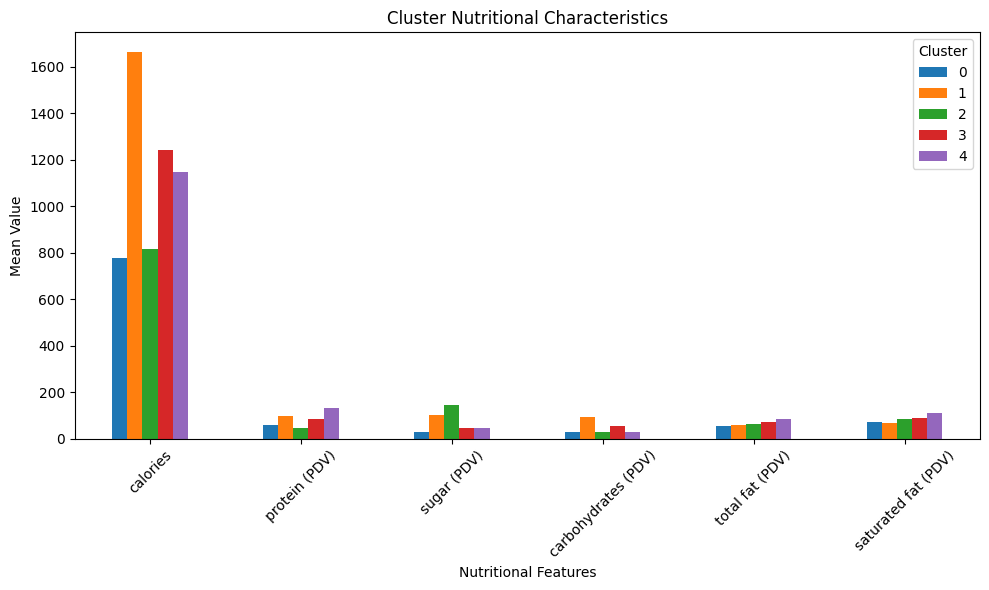

In [ ]:

data_with_clusters = data.copy()
data_with_clusters['Cluster'] = cluster_labels


numeric_columns = ['calories', 'protein (PDV)', 'sugar (PDV)', 
                   'carbohydrates (PDV)', 'total fat (PDV)', 
                   'saturated fat (PDV)']

cluster_summary = data_with_clusters.groupby('Cluster')[numeric_columns].mean()

cluster_summary = cluster_summary.round(2)


print("Cluster Summary (Mean Nutritional Values):")
print(cluster_summary)


# cluster_summary.to_csv("cluster_summary.csv")
# print("\nCluster summary saved to 'cluster_summary.csv'.")


import matplotlib.pyplot as plt


cluster_summary.T.plot(kind='bar', figsize=(10, 6), title="Cluster Nutritional Characteristics")
plt.ylabel("Mean Value")
plt.xlabel("Nutritional Features")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# Cluster 0:

# Low to moderate calorie recipes.
# Lower sugar content with balanced protein and fat.
# Could represent healthier, protein-balanced meals.
# Cluster 1:

# Very high-calorie recipes with a high combination of protein, sugar, and carbs.
# Likely energy-dense meals or high-carb options (e.g., large portions or hearty dishes).
# Cluster 2:

# Moderate calorie recipes with very high sugar.
# These are likely desserts or sweet-heavy recipes.
# Cluster 3:

# High-calorie, protein-rich, and moderate sugar recipes.
# Could represent balanced meals with protein and carbs.
# Cluster 4:

# High protein and high fat recipes.
# Possibly protein-dense options like keto meals or meat-heavy dishes.


In [46]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

# Load clustered dataset
data = pd.read_csv("clustered_recipes.csv")

# Goal to Cluster Mapping
goal_cluster_mapping = {
    "weight_loss": 0,
    "weight_maintenance": 3,
    "muscle_gain": 4
}

# Function to calculate daily calorie needs
def calculate_calories(goal, weight, height, age, gender, activity_level):
    if gender == "male":
        bmr = 10 * weight + 6.25 * height - 5 * age + 5
    else:
        bmr = 10 * weight + 6.25 * height - 5 * age - 161

    activity_multiplier = {
        "sedentary": 1.2,
        "lightly_active": 1.375,
        "moderate": 1.55,
        "very_active": 1.725,
        "super_active": 1.9,
    }
    calories = bmr * activity_multiplier[activity_level]

    # Adjust for goal
    if goal == "weight_loss":
        calories -= 400
    elif goal == "muscle_gain":
        calories += 400

    return int(calories)

# Recommend meals based on cluster and user details
def recommend_meals(user_calories, dietary_preference, allergies, num_meals=3, goal="weight_maintenance"):
    # Determine cluster based on user goal
    preferred_cluster = goal_cluster_mapping.get(goal, None)
    filtered_data = data.copy()

    # Filter recipes by user preferences and cluster
    if preferred_cluster is not None:
        filtered_data = filtered_data[filtered_data["Cluster"] == preferred_cluster]

    if dietary_preference != "no_preference":
        filtered_data = filtered_data[filtered_data["tags"].str.contains(dietary_preference, case=False, na=False)]

    for allergy in allergies:
        filtered_data = filtered_data[~filtered_data["tags"].str.contains(allergy, case=False, na=False)]

    # Shuffle recipes
    recipes = filtered_data[["name", "calories", "protein (PDV)", "sugar (PDV)", "carbohydrates (PDV)", "Cluster"]]
    recipes = recipes.sample(frac=1, random_state=None).reset_index(drop=True)

    # Distribute calories across meals
    calories_per_meal = user_calories / num_meals
    selected_recipes = []
    total_calories = 0

    for _, recipe in recipes.iterrows():
        if total_calories + recipe["calories"] <= user_calories and recipe["calories"] <= calories_per_meal:
            selected_recipes.append(recipe)
            total_calories += recipe["calories"]

        if len(selected_recipes) == num_meals:
            break

    return pd.DataFrame(selected_recipes)

# Main function
def main(user_input):
    goal = user_input["goal"]
    activity_level = user_input["exercise"]
    weight = int(user_input["weight"])
    height = int(user_input["height"])
    age = int(user_input["age"])
    gender = user_input["gender"]
    dietary_preference = user_input["dietaryPreference"]
    allergies = user_input["allergies"]
    num_meals = int(user_input["numMeals"])

    # Calculate calorie requirements
    user_calories = calculate_calories(goal, weight, height, age, gender, activity_level)
    print(f"Daily Calorie Requirement: {user_calories} kcal")
    print(f"Calories per meal (split into {num_meals} meals): {user_calories / num_meals:.2f} kcal")

    # Recommend meals
    recommended_recipes = recommend_meals(user_calories, dietary_preference, allergies, num_meals, goal)
    print("\nRecommended Meals:")
    print(recommended_recipes)

    recommended_recipes.to_csv("recommended_meals.csv", index=False)
    print("\nRecommendations saved to 'recommended_meals.csv'.")


user_input = {
    "goal": "muscle_gain",  
    "exercise": "moderate",
    "age": "25",
    "weight": "70",
    "height": "175",
    "gender": "male",
    "dietaryPreference": "high-protein",
    "allergies": ["Dairy", "Gluten"],
    "numMeals": "4"
}

if __name__ == "__main__":
    main(user_input)


Daily Calorie Requirement: 2994 kcal
Calories per meal (split into 4 meals): 748.50 kcal

Recommended Meals:
                                                 name  calories  \
2                           oven baked orange chicken     692.7   
13                    easy chicken and pasta parmesan     726.6   
22  crispy cheddar and jalapeno coated chicken bre...     719.6   
57                            louisiana garlic shrimp     698.2   

    protein (PDV)  sugar (PDV)  carbohydrates (PDV)  Cluster  
2           122.0        120.0                 21.0        4  
13          112.0         19.0                 27.0        4  
22          116.0         43.0                 22.0        4  
57          115.0          1.0                 23.0        4  

Recommendations saved to 'recommended_meals.csv'.
